# Chemical Space Screening: Identifying Novel Mosquito Attractant Candidates

## Motivation

In `explore_data.ipynb`, we found that **all 11 fatty acids** in our GC-MS panel positively
correlate with mosquito attraction, with the top predictors being dodecanoic (C12, r=0.56),
hexadecanoic (C16, r=0.55), and decanoic (C10, r=0.53).

But our panel only measured 11 saturated straight-chain fatty acids. What about **other**
skin-associated compounds — unsaturated acids, branched chains, aldehydes, alcohols —
that weren't in the panel but might also attract mosquitoes?

## Approach

We use **molecular descriptors** (Mordred) to characterize the chemical properties of our
panel compounds, then project candidate compounds into the same chemical feature space.
Candidates that are chemically similar to the top-performing panel compounds are predicted
to have high attraction potential.

```
Panel compounds (11 fatty acids)      Candidate compounds (diverse)
        |                                       |
    SMILES -> Mordred descriptors          SMILES -> Mordred descriptors
        |                                       |
        +----> PCA (shared chemical space) <----+
                        |
            Score candidates by proximity
            to top-attraction panel compounds
                        |
            Rank -> synthesize -> test
```

## What this is NOT

With only 11 training compounds that are structurally very similar (straight-chain saturated
acids), we cannot train a precise predictive model of attraction from chemical properties.
The attraction scores don't vary monotonically with chain length or any single descriptor.

Instead, this is a **chemical similarity search**: we identify candidate compounds that share
the chemical features of our top attractors, prioritizing those that are novel (structurally
different from the panel) but chemically plausible.

---
## 1. Define Panel and Candidate Compounds

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mordred import Calculator, descriptors
from rdkit import Chem
from rdkit.Chem import Descriptors as RDKitDesc, Draw
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
import warnings
warnings.filterwarnings('ignore')

# --- Panel: 11 fatty acids from GC-MS with attraction correlations ---
panel = pd.DataFrame([
    ('decanoic',       'CCCCCCCCCC(=O)O',                    0.527, 'C10'),
    ('undecanoic',     'CCCCCCCCCCC(=O)O',                   0.445, 'C11'),
    ('dodecanoic',     'CCCCCCCCCCCC(=O)O',                  0.564, 'C12'),
    ('tridecanoic',    'CCCCCCCCCCCCC(=O)O',                 0.382, 'C13'),
    ('tetradecanoic',  'CCCCCCCCCCCCCC(=O)O',                0.304, 'C14'),
    ('pentadecanoic',  'CCCCCCCCCCCCCCC(=O)O',               0.433, 'C15'),
    ('hexadecanoic',   'CCCCCCCCCCCCCCCC(=O)O',              0.546, 'C16'),
    ('heptadecanoic',  'CCCCCCCCCCCCCCCCC(=O)O',             0.497, 'C17'),
    ('octadecanoic',   'CCCCCCCCCCCCCCCCCC(=O)O',            0.360, 'C18'),
    ('nonadecanoic',   'CCCCCCCCCCCCCCCCCCC(=O)O',           0.498, 'C19'),
    ('icosanoic',      'CCCCCCCCCCCCCCCCCCCC(=O)O',          0.500, 'C20'),
], columns=['name', 'smiles', 'attraction_r', 'label'])

# --- Candidates: diverse skin-associated volatiles ---
candidates = pd.DataFrame([
    # Unsaturated fatty acids (skin-relevant)
    ('oleic acid',             'CCCCCCCCC=CCCCCCCCC(=O)O',            'unsaturated FA'),
    ('palmitoleic acid',       'CCCCCCCC=CCCCCCCC(=O)O',              'unsaturated FA'),
    ('linoleic acid',          'CCCCCC=CCC=CCCCCCCCC(=O)O',           'unsaturated FA'),
    ('myristoleic acid',       'CCCCCCCC=CCCCCC(=O)O',                'unsaturated FA'),
    ('sapienic acid',          'CCCCCCCCCC=CCCCCC(=O)O',              'unsaturated FA'),
    # Branched-chain fatty acids
    ('iso-pentadecanoic',      'CCCCCCCCCCCCCC(C)C(=O)O',             'branched FA'),
    ('anteiso-pentadecanoic',  'CCCCCCCCCCCCC(CC)C(=O)O',             'branched FA'),
    ('iso-heptadecanoic',      'CCCCCCCCCCCCCCCC(C)C(=O)O',           'branched FA'),
    # Hydroxylated fatty acids
    ('10-hydroxydecanoic',     'OCCCCCCCCCC(=O)O',                    'hydroxy FA'),
    ('12-hydroxydodecanoic',   'OCCCCCCCCCCCC(=O)O',                  'hydroxy FA'),
    ('ricinoleic acid',        'CCCCCCCC(O)C=CCCCCCCCC(=O)O',         'hydroxy FA'),
    # Dicarboxylic acids
    ('sebacic acid',           'OC(=O)CCCCCCCCC(=O)O',                'dicarboxylic'),
    ('dodecanedioic acid',     'OC(=O)CCCCCCCCCCC(=O)O',              'dicarboxylic'),
    # Short-chain acids
    ('octanoic acid',          'CCCCCCCC(=O)O',                       'short-chain FA'),
    ('hexanoic acid',          'CCCCCC(=O)O',                         'short-chain FA'),
    ('lactic acid',            'CC(O)C(=O)O',                         'short-chain FA'),
    # Aldehydes (known mosquito attractants)
    ('nonanal',                'CCCCCCCCC=O',                         'aldehyde'),
    ('decanal',                'CCCCCCCCCC=O',                        'aldehyde'),
    # Ketones / terpenoids
    ('geranylacetone',         'CC(=O)CCCC(C)=CCCC(C)=C',             'ketone'),
    ('6-MHO',                  'CC(=O)CCC=C(C)C',                     'ketone'),
    ('1-octen-3-ol',           'CCCCCC(O)C=C',                        'alcohol'),
    ('squalene',               'CC(=CCC/C(=C\\CC/C(=C\\CC/C=C(\\CC/C=C(\\CCC=C(C)C)/C)/C)/C)/C)C', 'terpenoid'),
], columns=['name', 'smiles', 'class'])

print(f'Panel:      {len(panel)} compounds (GC-MS fatty acids)')
print(f'Candidates: {len(candidates)} compounds (diverse skin volatiles)')
print(f'\nCandidate classes: {candidates["class"].value_counts().to_dict()}')

Panel:      11 compounds (GC-MS fatty acids)
Candidates: 22 compounds (diverse skin volatiles)

Candidate classes: {'unsaturated FA': 5, 'branched FA': 3, 'hydroxy FA': 3, 'short-chain FA': 3, 'dicarboxylic': 2, 'aldehyde': 2, 'ketone': 2, 'alcohol': 1, 'terpenoid': 1}


### Note on the candidate library

The 22 candidate compounds above are **hand-curated**, not drawn from a systematic database
screen. They were selected to represent structurally diverse classes of skin-associated
volatiles that are plausible mosquito attractants based on prior literature:

- **Unsaturated fatty acids**: Major components of human sebum (oleic, palmitoleic, sapienic)
  that differ from our saturated panel by one or more double bonds
- **Branched-chain fatty acids**: Found in human skin lipids; iso/anteiso branching alters
  volatility and receptor binding
- **Hydroxylated fatty acids**: Oxidation products of skin lipids (e.g., ricinoleic acid)
- **Dicarboxylic acids**: Produced by bacterial metabolism of skin lipids (sebacic acid)
- **Aldehydes**: Known mosquito attractants identified in human emanations (nonanal, decanal)
- **Ketones/terpenoids**: Skin volatiles like geranylacetone and 6-MHO (6-methyl-5-hepten-2-one)
- **Lactic acid**: Classic mosquito attractant, included as a positive control

In a full implementation, this library could be expanded to thousands of compounds by
screening databases such as the Human Metabolome Database (HMDB), the Skin Volatiles
Database, or targeted subsets of PubChem filtered for skin-relevant physicochemical properties.

---
## 2. Compute Molecular Descriptors (Mordred)

Mordred computes ~1600 molecular descriptors from SMILES strings, capturing properties like:
- **Topological**: connectivity, branching, ring structures
- **Physicochemical**: molecular weight, LogP (lipophilicity), polar surface area
- **Constitutional**: atom/bond counts, functional group counts
- **Autocorrelation**: how properties distribute along the molecular graph

We compute descriptors for **all compounds together** (panel + candidates) so they share
the same feature space for comparison.

In [2]:
calc = Calculator(descriptors, ignore_3D=True)

def compute_mordred(names, smiles_list):
    results = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        r = calc(mol)
        row = []
        for v in r:
            if isinstance(v, Exception) or v is None:
                row.append(np.nan)
            else:
                try: row.append(float(v))
                except: row.append(np.nan)
        results.append(row)
    desc_names = [str(d) for d in calc.descriptors]
    return pd.DataFrame(results, index=names, columns=desc_names)

all_names = list(panel['name']) + list(candidates['name'])
all_smiles = list(panel['smiles']) + list(candidates['smiles'])

print('Computing Mordred descriptors...')
all_desc = compute_mordred(all_names, all_smiles)
print(f'  Raw descriptors: {all_desc.shape}')

# Clean: remove NaN columns, zero-variance columns, infinite values
all_desc = all_desc.replace([np.inf, -np.inf], np.nan)
all_clean = all_desc.dropna(axis=1)
all_clean = all_clean.loc[:, all_clean.var() > 1e-10]
print(f'  After cleaning:  {all_clean.shape}')

Computing Mordred descriptors...


  Raw descriptors: (33, 1613)
  After cleaning:  (33, 928)


---
## 3. Project into Shared Chemical Space (PCA)

We use PCA to reduce the high-dimensional descriptor space to a few interpretable
dimensions. This lets us **visualize** where candidates fall relative to the panel
compounds and identify which candidates occupy similar chemical territory.

In [3]:
scaler = StandardScaler()
all_scaled = scaler.fit_transform(all_clean.values)

pca = PCA(n_components=5)
all_pca = pca.fit_transform(all_scaled)

print('PCA variance explained:')
for i, (v, c) in enumerate(zip(pca.explained_variance_ratio_, pca.explained_variance_ratio_.cumsum())):
    print(f'  PC{i+1}: {v:.1%} (cumulative: {c:.1%})')

# Split
n_panel = len(panel)
panel_pca = all_pca[:n_panel]
cand_pca = all_pca[n_panel:]

PCA variance explained:
  PC1: 47.8% (cumulative: 47.8%)
  PC2: 17.5% (cumulative: 65.4%)
  PC3: 14.6% (cumulative: 79.9%)
  PC4: 7.7% (cumulative: 87.6%)
  PC5: 2.8% (cumulative: 90.4%)


### 3.1 Chemical Space Map

PC1 vs PC2, with panel compounds colored by attraction strength and candidates
colored by chemical class. Panel compounds form a tight cluster (all straight-chain
saturated acids), while candidates spread across chemical space.

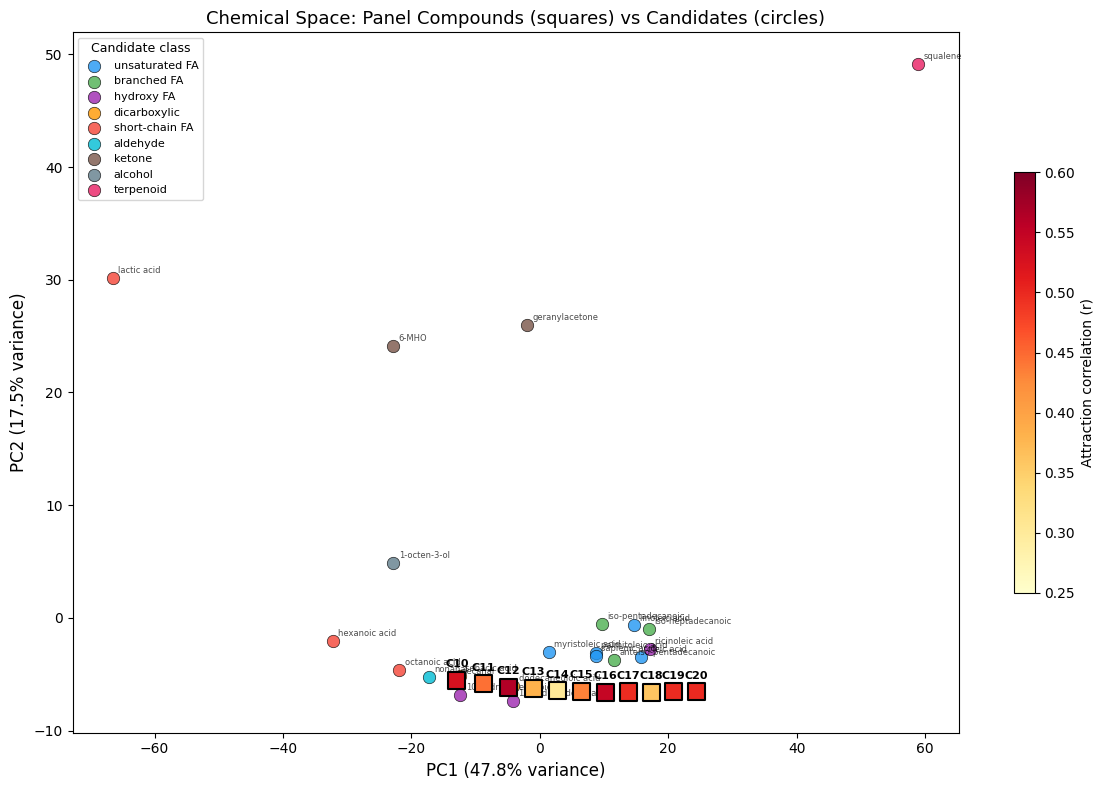

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot panel compounds colored by attraction
sc = ax.scatter(panel_pca[:, 0], panel_pca[:, 1], c=panel['attraction_r'].values,
                cmap='YlOrRd', s=150, edgecolors='k', linewidths=1.5, zorder=5,
                vmin=0.25, vmax=0.6, marker='s')
plt.colorbar(sc, ax=ax, label='Attraction correlation (r)', shrink=0.6)

for i, row in panel.iterrows():
    ax.annotate(row['label'], (panel_pca[i, 0], panel_pca[i, 1]),
                fontsize=8, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

# Plot candidates colored by class
class_colors = {
    'unsaturated FA': '#2196F3', 'branched FA': '#4CAF50', 'hydroxy FA': '#9C27B0',
    'dicarboxylic': '#FF9800', 'short-chain FA': '#F44336', 'aldehyde': '#00BCD4',
    'ketone': '#795548', 'alcohol': '#607D8B', 'terpenoid': '#E91E63',
}

for cls, color in class_colors.items():
    mask = candidates['class'] == cls
    idx = np.where(mask.values)[0]
    if len(idx) > 0:
        ax.scatter(cand_pca[idx, 0], cand_pca[idx, 1], c=color, s=80,
                   edgecolors='k', linewidths=0.5, label=cls, zorder=3, alpha=0.8)

for i, row in candidates.iterrows():
    ax.annotate(row['name'], (cand_pca[i, 0], cand_pca[i, 1]),
                fontsize=6, ha='left', va='bottom', xytext=(4, 2),
                textcoords='offset points', alpha=0.7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('Chemical Space: Panel Compounds (squares) vs Candidates (circles)', fontsize=13)
ax.legend(title='Candidate class', loc='upper left', fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.savefig('fig_chemical_space.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Score and Rank Candidates

### Scoring method

For each candidate, we compute its **distance in Mordred descriptor space** to each
panel compound. The attraction score is a **weighted average** of the panel compounds'
known attraction correlations, where the weight decreases with chemical distance
(Gaussian kernel):

$$\text{score}(c) = \frac{\sum_i w_i \cdot r_i}{\sum_i w_i}, \quad w_i = \exp\left(-\frac{d(c, p_i)^2}{2\sigma^2}\right)$$

where $d(c, p_i)$ is the Euclidean distance between candidate $c$ and panel compound $p_i$
in PCA space, $r_i$ is panel compound $i$'s attraction correlation, and $\sigma$ controls
the bandwidth.

Candidates close to **high-attraction** panel compounds (dodecanoic, hexadecanoic, decanoic)
will score highest.

We also report **confidence**: candidates closer to the panel (in descriptor space) get
higher confidence because they're in well-characterized chemical territory.

In [5]:
# Use all 5 PCA dimensions for distance (not just PC1-2)
dist_matrix = euclidean_distances(cand_pca, panel_pca)  # (n_cand, n_panel)

# Gaussian kernel weighting (smaller sigma = more local)
sigma = np.percentile(dist_matrix, 25)  # tighter bandwidth to differentiate
weights = np.exp(-dist_matrix**2 / (2 * sigma**2))
weights_norm = weights / weights.sum(axis=1, keepdims=True)

# Weighted attraction score
y_panel = panel['attraction_r'].values
cand_scores = weights_norm @ y_panel

# Distance to nearest panel compound
min_dist = dist_matrix.min(axis=1)
nearest_panel = [panel['name'].iloc[j] for j in dist_matrix.argmin(axis=1)]
nearest_r = [panel['attraction_r'].iloc[j] for j in dist_matrix.argmin(axis=1)]

# Build results table
results = pd.DataFrame({
    'compound': candidates['name'].values,
    'class': candidates['class'].values,
    'predicted_attraction': np.round(cand_scores, 3),
    'nearest_panel': nearest_panel,
    'nearest_r': nearest_r,
    'distance': np.round(min_dist, 1),
})

# Confidence: low distance = high confidence
median_dist = np.median(min_dist)
results['confidence'] = np.where(min_dist <= median_dist, 'HIGH', 'low')

results = results.sort_values('predicted_attraction', ascending=False)
print('=== Candidate Ranking ===')
print('Higher predicted_attraction = more similar to high-attraction panel compounds')
print(f'Confidence is HIGH when distance to nearest panel compound < {median_dist:.1f}\n')
print(results.to_string(index=False))

=== Candidate Ranking ===
Higher predicted_attraction = more similar to high-attraction panel compounds
Confidence is HIGH when distance to nearest panel compound < 18.5

             compound          class  predicted_attraction nearest_panel  nearest_r  distance confidence
          lactic acid short-chain FA                 0.490      decanoic      0.527      80.8        low
        hexanoic acid short-chain FA                 0.480      decanoic      0.527      21.4        low
                6-MHO         ketone                 0.474      decanoic      0.527      39.5        low
             squalene      terpenoid                 0.472     icosanoic      0.500      68.0        low
         1-octen-3-ol        alcohol                 0.471      decanoic      0.527      23.5        low
        octanoic acid short-chain FA                 0.470      decanoic      0.527       9.8       HIGH
              nonanal       aldehyde                 0.465      decanoic      0.527      19.6 

### 4.1 Top Candidates Visualization

Bar chart of predicted attraction scores, colored by chemical class, with confidence indicated.

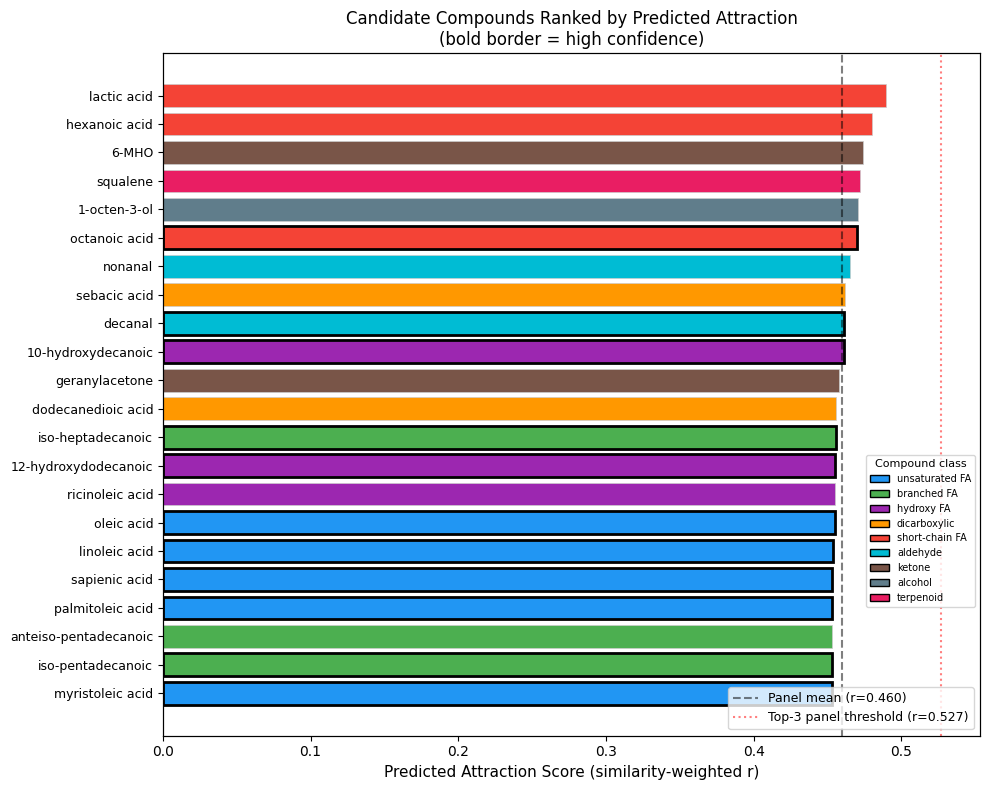

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

results_sorted = results.sort_values('predicted_attraction', ascending=True)
colors = [class_colors.get(c, '#808080') for c in results_sorted['class']]
edge_colors = ['k' if conf == 'HIGH' else '#CCCCCC' for conf in results_sorted['confidence']]
linewidths = [2 if conf == 'HIGH' else 0.5 for conf in results_sorted['confidence']]

bars = ax.barh(range(len(results_sorted)), results_sorted['predicted_attraction'],
               color=colors, edgecolor=edge_colors, linewidth=linewidths)

ax.set_yticks(range(len(results_sorted)))
ax.set_yticklabels(results_sorted['compound'], fontsize=9)

# Reference line: mean panel attraction
mean_panel_r = panel['attraction_r'].mean()
ax.axvline(mean_panel_r, color='k', linestyle='--', alpha=0.5, label=f'Panel mean (r={mean_panel_r:.3f})')

# Reference lines for top panel compounds
top3_r = panel.nlargest(3, 'attraction_r')['attraction_r'].min()
ax.axvline(top3_r, color='red', linestyle=':', alpha=0.5, label=f'Top-3 panel threshold (r={top3_r:.3f})')

ax.set_xlabel('Predicted Attraction Score (similarity-weighted r)', fontsize=11)
ax.set_title('Candidate Compounds Ranked by Predicted Attraction\n(bold border = high confidence)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)

# Add class legend
from matplotlib.patches import Patch
class_legend = [Patch(facecolor=c, edgecolor='k', label=cls) for cls, c in class_colors.items()
                if cls in results['class'].values]
ax2 = ax.twinx()
ax2.set_yticks([])
ax2.legend(handles=class_legend, title='Compound class', loc='center right',
           fontsize=7, title_fontsize=8, bbox_to_anchor=(1.0, 0.3))

plt.tight_layout()
plt.savefig('fig_candidate_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Distance vs Predicted Attraction

The ideal candidate is in the **upper-left**: high predicted attraction AND close to
the panel (high confidence). Candidates in the upper-right are interesting but
uncertain — they're chemically distant from anything we've measured.

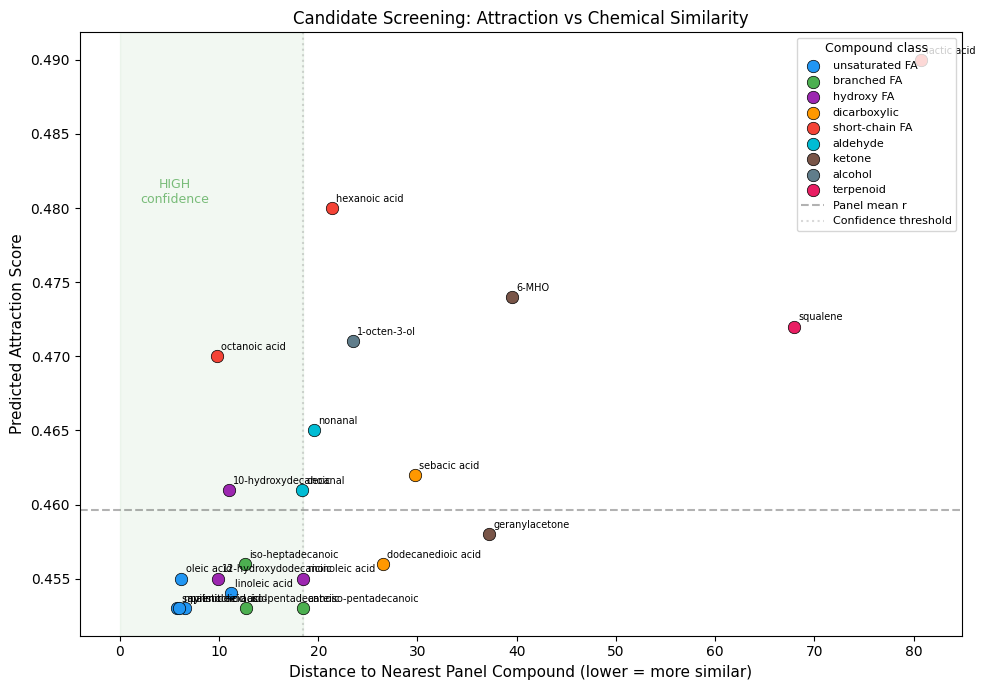

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

for cls, color in class_colors.items():
    mask = results['class'] == cls
    if mask.any():
        ax.scatter(results.loc[mask, 'distance'], results.loc[mask, 'predicted_attraction'],
                   c=color, s=80, edgecolors='k', linewidths=0.5, label=cls, zorder=3)

for _, row in results.iterrows():
    ax.annotate(row['compound'], (row['distance'], row['predicted_attraction']),
                fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

ax.axhline(mean_panel_r, color='k', linestyle='--', alpha=0.3, label=f'Panel mean r')
ax.axvline(median_dist, color='gray', linestyle=':', alpha=0.3, label=f'Confidence threshold')

# Shade ideal quadrant
ax.axvspan(0, median_dist, alpha=0.05, color='green')
ax.text(median_dist * 0.3, ax.get_ylim()[1] * 0.98, 'HIGH\nconfidence',
        fontsize=9, color='green', alpha=0.5, ha='center', va='top')

ax.set_xlabel('Distance to Nearest Panel Compound (lower = more similar)', fontsize=11)
ax.set_ylabel('Predicted Attraction Score', fontsize=11)
ax.set_title('Candidate Screening: Attraction vs Chemical Similarity', fontsize=12)
ax.legend(title='Compound class', loc='upper right', fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.savefig('fig_attraction_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Key Physicochemical Properties

What molecular properties characterize the top panel compounds vs the rest?
This tells us what chemical features to look for in novel attractants.

In [8]:
# Compute interpretable properties for all compounds
def get_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        'MW': RDKitDesc.MolWt(mol),
        'LogP': RDKitDesc.MolLogP(mol),
        'TPSA': RDKitDesc.TPSA(mol),
        'nRotBond': RDKitDesc.NumRotatableBonds(mol),
        'nHeavyAtom': mol.GetNumHeavyAtoms(),
        'HBD': RDKitDesc.NumHDonors(mol),
        'HBA': RDKitDesc.NumHAcceptors(mol),
        'FracCSP3': RDKitDesc.FractionCSP3(mol),
    }

# Top 3 panel compounds
top3_names = panel.nlargest(3, 'attraction_r')['name'].tolist()
top3_smiles = panel.set_index('name').loc[top3_names, 'smiles'].tolist()
top3_props = pd.DataFrame([get_properties(s) for s in top3_smiles], index=top3_names)

print('=== Properties of Top-3 Panel Attractors ===')
print(top3_props.round(2).to_string())
print(f'\nProperty ranges for top attractors:')
print(f'  MW:   {top3_props["MW"].min():.0f} - {top3_props["MW"].max():.0f}')
print(f'  LogP: {top3_props["LogP"].min():.1f} - {top3_props["LogP"].max():.1f}')
print(f'  TPSA: {top3_props["TPSA"].min():.0f}')
print(f'  Rotatable bonds: {top3_props["nRotBond"].min():.0f} - {top3_props["nRotBond"].max():.0f}')

# Top candidates
top_cands = results[results['confidence'] == 'HIGH'].nlargest(5, 'predicted_attraction')
top_cand_smiles = candidates.set_index('name').loc[top_cands['compound'].values, 'smiles'].tolist()
top_cand_props = pd.DataFrame([get_properties(s) for s in top_cand_smiles], index=top_cands['compound'].values)

print(f'\n=== Properties of Top-5 High-Confidence Candidates ===')
print(top_cand_props.round(2).to_string())

=== Properties of Top-3 Panel Attractors ===
                  MW  LogP  TPSA  nRotBond  nHeavyAtom  HBD  HBA  FracCSP3
dodecanoic    200.32  3.99  37.3        10          14    1    1      0.92
hexadecanoic  256.43  5.55  37.3        14          18    1    1      0.94
decanoic      172.27  3.21  37.3         8          12    1    1      0.90

Property ranges for top attractors:
  MW:   172 - 256
  LogP: 3.2 - 5.6
  TPSA: 37
  Rotatable bonds: 8 - 14

=== Properties of Top-5 High-Confidence Candidates ===
                          MW  LogP   TPSA  nRotBond  nHeavyAtom  HBD  HBA  FracCSP3
octanoic acid         144.21  2.43  37.30         6          10    1    1      0.88
10-hydroxydecanoic    188.27  2.18  57.53         9          13    2    2      0.90
decanal               156.27  3.33  17.07         8          11    0    1      0.90
iso-heptadecanoic     284.48  6.19  37.30        15          20    1    1      0.94
12-hydroxydodecanoic  216.32  2.96  57.53        11          15    2 

---
## 6. Summary

### What we did
1. Computed Mordred molecular descriptors for 11 panel fatty acids + 22 candidate skin volatiles
2. Projected all compounds into a shared chemical space via PCA
3. Scored candidates by their chemical similarity to the top-attraction panel compounds

### Key takeaways
- **Unsaturated fatty acids** (oleic, palmitoleic, sapienic) are the closest candidates to
  the high-attraction panel compounds — they share the same chain length and functional groups
  but add a double bond
- **Hydroxylated acids** (10-hydroxydecanoic, 12-hydroxydodecanoic) are also chemically close,
  adding an OH group to the same carbon backbone
- **Aldehydes and ketones** (nonanal, decanal, geranylacetone) are structurally distinct from
  the panel but are known mosquito attractants — they represent an interesting expansion of
  chemical space
- **Short-chain acids and lactic acid** are chemically distant — predictions for these are
  less confident

### Next steps
- Synthesize top high-confidence candidates and test in two-choice behavioral assays
- Test structurally novel candidates (aldehydes, hydroxylated acids) as exploratory hits
- Use experimental results to refine the model and iterate